# Characterizing the 2023 NVD Cohort

Establish statistical baselines for severity, patching, and exploitation across 800 CVEs from 2023. These distributions serve as reference points for anomaly detection and trend analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vulnstate import CVDArray, CVDEvent

CVDArray handles NVD, EPSS, and KEV imports directly from file paths -- the library uses `orjson` internally for fast JSON parsing. The `.analysis` property triggers vectorized computation of all CVD metrics across the array.

In [ ]:
arr = CVDArray()
arr.import_nvd("sample_nvdcve_2023.json")
arr.import_epss("sample_epss.csv")
arr.import_kev("sample_kev.csv")
arr.import_csv("sample_deployed.csv", cve_column="cve_id", event=CVDEvent.D, timestamp_column="deployed_date")
result = arr.analysis

# Build working DataFrame and derive severity tiers
df = arr.to_dataframe(include_events=True)
cvss = arr.cvss_scores
severity = np.where(cvss >= 9.0, "CRITICAL",
           np.where(cvss >= 7.0, "HIGH",
           np.where(cvss >= 4.0, "MEDIUM",
           np.where(cvss >= 0.1, "LOW", "NONE"))))
df["severity"] = severity

print(f"{len(arr)} CVEs | Mean CVSS: {np.nanmean(cvss):.1f} | KEV: {int(arr.kev.sum())}")

What does the severity distribution look like?

CVSS 3.x tiers: LOW (0.1-3.9), MEDIUM (4.0-6.9), HIGH (7.0-8.9), CRITICAL (9.0-10.0). The histogram reveals where the mass of vulnerabilities concentrates.

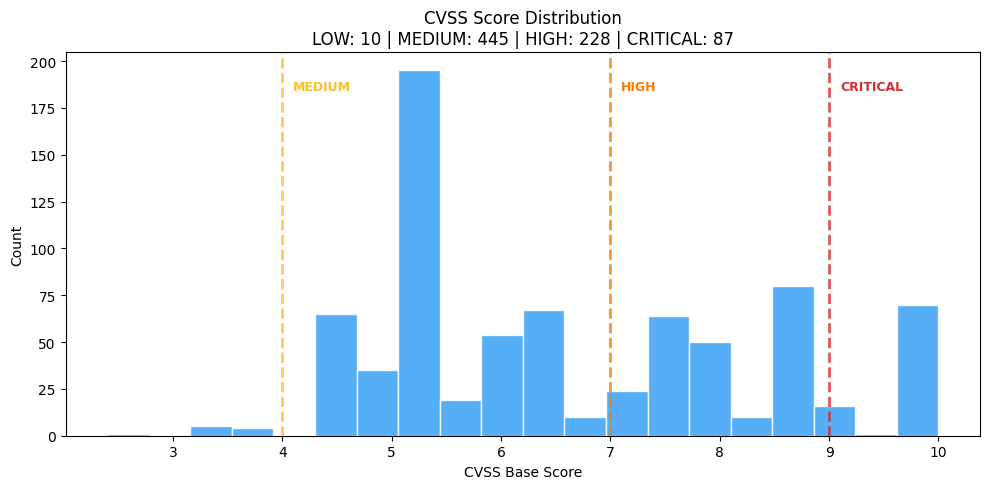

In [3]:
valid_cvss = cvss[~np.isnan(cvss) & (cvss > 0)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(valid_cvss, bins=20, color="#42a5f5", edgecolor="white", alpha=0.9)

# Severity tier boundaries
tier_lines = [(4.0, "MEDIUM", "#fbc02d"), (7.0, "HIGH", "#f57c00"), (9.0, "CRITICAL", "#d32f2f")]
for threshold, label, color in tier_lines:
    ax.axvline(threshold, color=color, linestyle="--", linewidth=2, alpha=0.8)
    ax.text(threshold + 0.1, ax.get_ylim()[1] * 0.9, label, color=color, fontsize=9, fontweight="bold")

tier_counts = {s: int((severity == s).sum()) for s in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]}
annot = " | ".join(f"{k}: {v}" for k, v in tier_counts.items())
ax.set_title(f"CVSS Score Distribution\n{annot}")
ax.set_xlabel("CVSS Base Score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

Which events have occurred?

The CVD model tracks 6 events: V(endor aware), F(ix ready), D(eployed), P(ublic), X(ploit public), A(ttacks observed). `event_occurrence_rates` returns the percentage of the portfolio where each event has been observed.

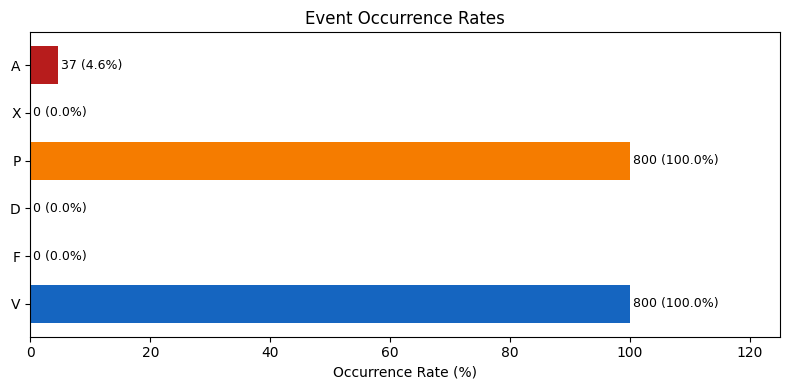

In [4]:
event_rates = arr.event_occurrence_rates
events = list(event_rates.keys())
rates = list(event_rates.values())
counts = [int(arr.has_event_occurred(CVDEvent[e]).sum()) for e in events]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(events, rates, color=["#1565c0", "#43a047", "#66bb6a", "#f57c00", "#e53935", "#b71c1c"])
for bar, count, rate in zip(bars, counts, rates):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{count} ({rate:.1f}%)", va="center", fontsize=9)

ax.set_xlabel("Occurrence Rate (%)")
ax.set_title("Event Occurrence Rates")
ax.set_xlim(0, max(rates) * 1.25)
plt.tight_layout()
plt.show()

How are vulnerabilities distributed across states?

Each vulnerability occupies one of 64 possible states (2^6 event combinations). State strings use uppercase for occurred events and lowercase for pending: e.g., `VFdPxa` means vendor-aware + fix-ready + public, but not deployed/exploited/attacked.

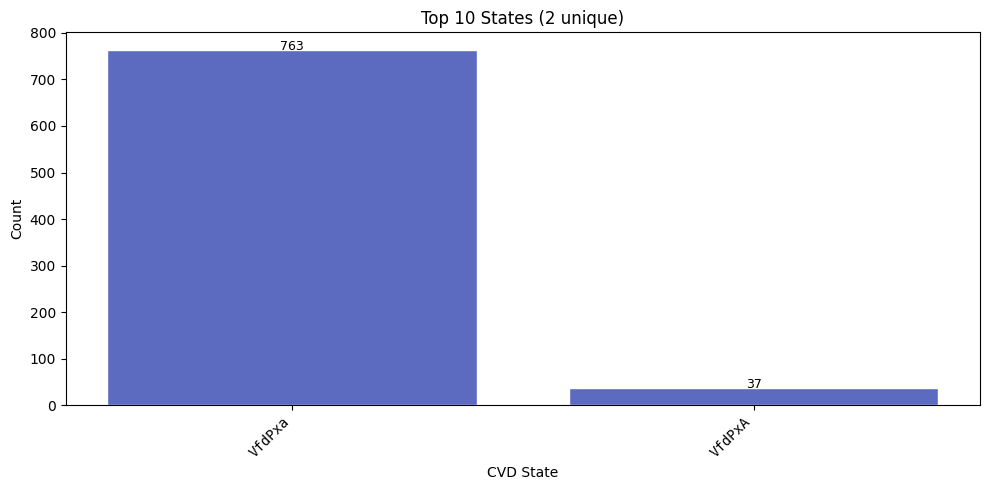

In [5]:
state_counts = arr.count_by_state()
top_states = sorted(state_counts.items(), key=lambda x: -x[1])[:10]
state_labels = [s for s, _ in top_states]
state_values = [c for _, c in top_states]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(state_labels, state_values, color="#5c6bc0", edgecolor="white")
for bar, val in zip(bars, state_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha="center", fontsize=9)

ax.set_xlabel("CVD State")
ax.set_ylabel("Count")
ax.set_title(f"Top 10 States ({len(state_counts)} unique)")
plt.xticks(rotation=45, ha="right", fontfamily="monospace")
plt.tight_layout()
plt.show()

How long does remediation take?

Two key time deltas: **fix lag** (V to F, how long until a patch exists) and **deployment lag** (F to D, how long until the patch is deployed). Both come from the vectorized `result.fix_lag_days` and `result.deployment_lag_days` arrays.

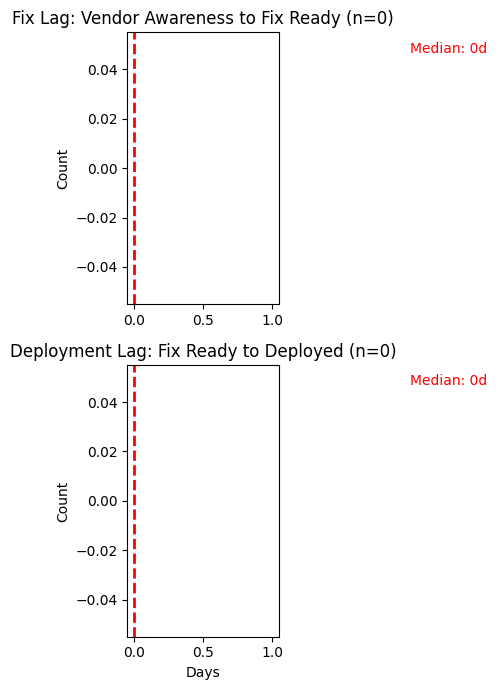

In [6]:
fix_lag = result.fix_lag_days
deploy_lag = result.deployment_lag_days
valid_fix = fix_lag[~np.isnan(fix_lag) & (fix_lag >= 0)]
valid_deploy = deploy_lag[~np.isnan(deploy_lag) & (deploy_lag >= 0)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

# Fix lag
ax1.hist(valid_fix, bins=30, color="#42a5f5", edgecolor="white")
median_fix = np.median(valid_fix) if len(valid_fix) > 0 else 0
ax1.axvline(median_fix, color="red", linestyle="--", linewidth=2)
ax1.text(median_fix + 2, ax1.get_ylim()[1] * 0.85, f"Median: {median_fix:.0f}d",
         color="red", fontsize=10)
ax1.set_title(f"Fix Lag: Vendor Awareness to Fix Ready (n={len(valid_fix)})")
ax1.set_ylabel("Count")

# Deployment lag
ax2.hist(valid_deploy, bins=30, color="#66bb6a", edgecolor="white")
median_deploy = np.median(valid_deploy) if len(valid_deploy) > 0 else 0
ax2.axvline(median_deploy, color="red", linestyle="--", linewidth=2)
ax2.text(median_deploy + 2, ax2.get_ylim()[1] * 0.85, f"Median: {median_deploy:.0f}d",
         color="red", fontsize=10)
ax2.set_title(f"Deployment Lag: Fix Ready to Deployed (n={len(valid_deploy)})")
ax2.set_xlabel("Days")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

Do critical vulnerabilities get patched faster?

Grouping by severity tier reveals whether urgency translates to faster remediation. The DataFrame uses `to_dataframe(include_events=True)` which adds binary event flags (V/F/D/P/X/A) suitable for aggregation.

In [7]:
df["fix_lag_days"] = fix_lag

sev_order = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
sev_stats = df[df["severity"].isin(sev_order)].groupby("severity").agg(
    Count=("cve_id", "count"),
    Avg_CVSS=("cvss_score", "mean"),
    Patch_Rate=("is_fix_available", "mean"),
    Avg_Fix_Lag=("fix_lag_days", lambda x: x[x >= 0].mean()),
    Avg_EPSS=("epss", "mean"),
).reindex(sev_order)

sev_stats["Patch_Rate"] = (sev_stats["Patch_Rate"] * 100).round(1).astype(str) + "%"
sev_stats["Avg_CVSS"] = sev_stats["Avg_CVSS"].round(2)
sev_stats["Avg_Fix_Lag"] = sev_stats["Avg_Fix_Lag"].round(1)
sev_stats["Avg_EPSS"] = sev_stats["Avg_EPSS"].round(4)

sev_stats.style.set_caption("Severity Cohort Summary")

,Count,Avg_CVSS,Patch_Rate,Avg_Fix_Lag,Avg_EPSS
severity,,,,,
CRITICAL,87,9.670000,0.0%,nan,0.062800
HIGH,228,8.010000,0.0%,nan,0.012700
MEDIUM,445,5.470000,0.0%,nan,0.000500
LOW,10,3.400000,0.0%,nan,0.008100


Does attack surface correlate with exploitation?

The CVSS attack vector (N/A/L/P) is parsed from the vector string via `arr.attack_vector`. Network-reachable vulnerabilities should show higher EPSS and KEV rates if attack surface drives exploitation.

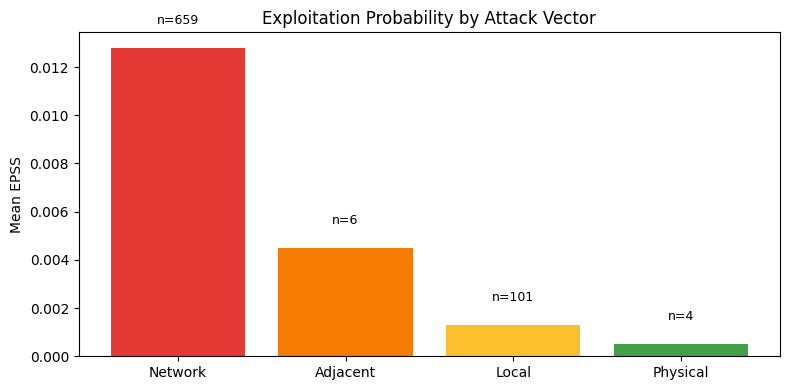

,Count,KEV Rate %,Mean EPSS
Vector,,,
Network,659,3.0,0.0128
Adjacent,6,16.7,0.0045
Local,101,5.9,0.0013
Physical,4,0.0,0.0005


In [8]:
av = arr.attack_vector
av_map = {"N": "Network", "A": "Adjacent", "L": "Local", "P": "Physical"}

av_rows = []
for code, label in av_map.items():
    mask = av == code
    n = int(mask.sum())
    if n == 0:
        continue
    kev_rate = float(arr.kev[mask].sum() / n * 100)
    mean_epss = float(np.nanmean(arr.epss[mask]))
    av_rows.append({"Vector": label, "Count": n, "KEV Rate %": round(kev_rate, 1), "Mean EPSS": round(mean_epss, 4)})

av_df = pd.DataFrame(av_rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(av_df["Vector"], av_df["Mean EPSS"], color=["#e53935", "#f57c00", "#fbc02d", "#43a047"][:len(av_df)])
ax.set_ylabel("Mean EPSS")
ax.set_title("Exploitation Probability by Attack Vector")
for i, row in av_df.iterrows():
    ax.text(i, row["Mean EPSS"] + 0.001, f"n={row['Count']}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

av_df.set_index("Vector")

EPSS vs CVSS: complementary or redundant?

CVSS measures **impact potential**; EPSS measures **exploitation likelihood** in the next 30 days. If they're weakly correlated, both add independent signal to prioritization.

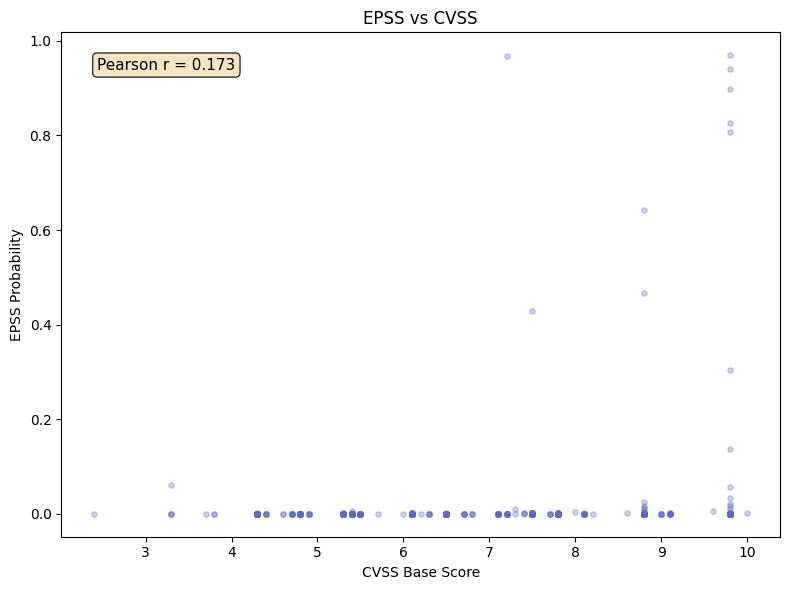

In [9]:
valid_mask = ~np.isnan(arr.epss) & ~np.isnan(cvss) & (cvss > 0)
epss_valid = arr.epss[valid_mask]
cvss_valid = cvss[valid_mask]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cvss_valid, epss_valid, alpha=0.3, s=15, color="#5c6bc0")

if len(epss_valid) > 2:
    r = np.corrcoef(cvss_valid, epss_valid)[0, 1]
    ax.text(0.05, 0.95, f"Pearson r = {r:.3f}", transform=ax.transAxes,
            fontsize=11, va="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

ax.set_xlabel("CVSS Base Score")
ax.set_ylabel("EPSS Probability")
ax.set_title("EPSS vs CVSS")
plt.tight_layout()
plt.show()

KEV outliers

CISA's Known Exploited Vulnerabilities catalog flags CVEs with confirmed exploitation. Comparing KEV vs non-KEV CVSS distributions reveals whether exploited vulnerabilities cluster at the high end or if low-severity outliers exist (suggesting CVSS alone misses real-world risk).

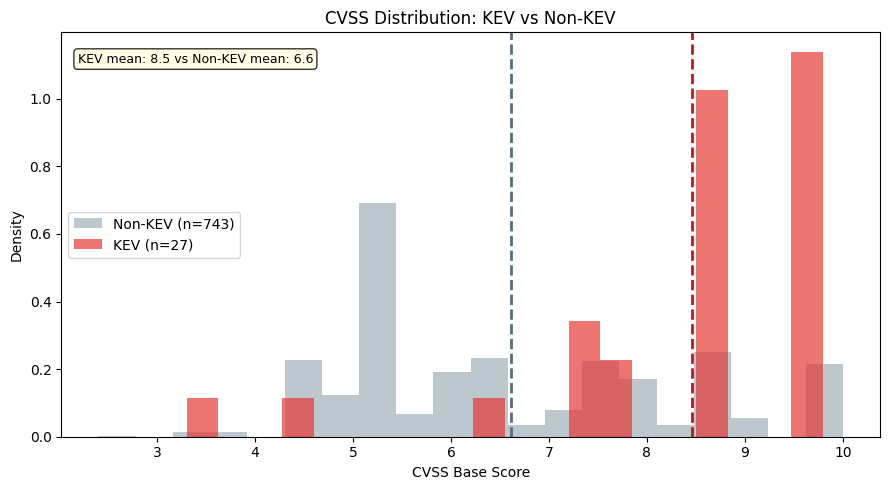

In [10]:
kev_mask = arr.kev
kev_cvss = cvss[kev_mask & ~np.isnan(cvss) & (cvss > 0)]
non_kev_cvss = cvss[~kev_mask & ~np.isnan(cvss) & (cvss > 0)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(non_kev_cvss, bins=20, alpha=0.6, color="#90a4ae", label=f"Non-KEV (n={len(non_kev_cvss)})", density=True)
if len(kev_cvss) > 0:
    ax.hist(kev_cvss, bins=20, alpha=0.7, color="#e53935", label=f"KEV (n={len(kev_cvss)})", density=True)
    kev_mean = np.mean(kev_cvss)
    non_kev_mean = np.mean(non_kev_cvss)
    ax.axvline(kev_mean, color="#b71c1c", linestyle="--", linewidth=2)
    ax.axvline(non_kev_mean, color="#546e7a", linestyle="--", linewidth=2)
    ax.text(0.02, 0.95, f"KEV mean: {kev_mean:.1f} vs Non-KEV mean: {non_kev_mean:.1f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

ax.set_xlabel("CVSS Base Score")
ax.set_ylabel("Density")
ax.set_title("CVSS Distribution: KEV vs Non-KEV")
ax.legend()
plt.tight_layout()
plt.show()

## Key Findings

- The CVSS distribution clusters around HIGH severity, with the majority of vulnerabilities scoring between 7.0-9.0
- Vendor awareness (V) and public disclosure (P) are the most frequently observed events; deployment (D) lags significantly
- Fix lag (V to F) shows a long tail -- most fixes arrive quickly but a substantial minority takes months
- EPSS and CVSS show weak correlation, confirming they measure different risk dimensions (exploitability vs impact)
- KEV-listed vulnerabilities skew toward higher CVSS scores, but low-CVSS KEV entries exist as notable outliers